# Bias Analysis on H-R Diagram with Gaia DR3 data

```Authors: Paul Alvarez updated: 20260718```

This notebook retrieves a study about the bias in distance-parallax measures. The analyze use Gaia data (via Astroquery) for a selected region of the sky (e.g., Pleiades) and computes stellar absolute magnitudes from parallax measurements, including a discussion about Lutz–Kelker bias associated with estimating distances using the naive inverse-parallax approach (1/parallax), and examines how the resulting Hertzsprung–Russell diagram changes when Bayesian distance estimates are used instead (based on Bailer-Jones paper approach) (This need to change a little bit; with greater enphasis in the analysis (i.e., bayesian distances) rather than compute the H-R diagram...).

## Table of contents:
* [Required libraries](#Required-libraries)
* [Introduction](#Introduction)
* [Data: Collection and Description](#Data:_Collection_and_Description)
* [Initial Approuch](#initial-naive-approuch)
* [Lutz-Kelker Bias](#lutz-kelker-bias)


## Required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

## Introduction 

The Hertzsprung-Russell diagram (HR diagram) is one of the most important tools in the study of stellar evolution. Developed independently in the early 1900s by Ejnar Hertzsprung and Henry Norris Russell, it plots the temperature of stars against their luminosity (the theoretical HR diagram), or the colour of stars (or spectral type) against their absolute magnitude (the observational HR diagram, also known as a colour-magnitude diagram, which we refers in this study).

Depending on its initial mass, every star goes through specific evolutionary stages dictated by its internal structure and how it produces energy. Each of these stages corresponds to a change in the temperature and luminosity of the star, which can be seen to move to different regions on the HR diagram as it evolves. This reveals the true power of the HR diagram – astronomers can know a star’s internal structure and evolutionary stage simply by determining its position in the diagram (COSMOS, Swinburne University of Technology).

However, the utility of the observational H-R diagram in understanding stellar formation and structure relies primarily on the assumption that the magnitude is unbiased (or, at least, not significantly so). In this context, a reliable distance is required to calculate the magnitude; otherwise, additional biases are introduced into the measurement process. This gives rise to the primary motivation for this study: to examine the widely used "naive" distance estimator, 1/ϖ, and its impact on absolute magnitude calculations and the resulting HR diagram, as well as to analyze and implement corrections for the associated biases, such as Bayesian distance estimates. In particular, we explore the construction of the Hertzsprung–Russell (H-R) diagram using Gaia DR3 data for the Pleiades star cluster in order to investigate the effects and limitations of estimating stellar distances from the inverse of the measured parallax, 


## Data: Collection and Description

To define the region of the GAIA data to be examined, we will use the celestial location of the Pleiades (M45) as a guide. Since it is a star cluster, we know that the stars formed at the same time and are all at the same distance from us, which results in less noise than other regions when using the stellar data for an HR diagram. It is also worth noting that we will not initially use reliability parameters(such as the commonly used RUWE (Renormalized Unit Weight Error) as a filter) in the queries; doing so would restrict the sample to stars with reliable and accurate measurements, thereby preventing us from assessing the impact of poor parallax measurements.

In [2]:
# Pleiades open cluster
ra_target = 56.75   
dec_target = 24.12 
radius_deg = 1

# Metadata for the study
query = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_error, 
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe,
    visibility_periods_used,
    astrometric_excess_noise,
    parallax_over_error
FROM gaiadr3.gaia_source
WHERE
    CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra_target}, {dec_target}, {radius_deg})
    ) = 1
    AND parallax > 0
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
"""

# Get the query results
job = Gaia.launch_job_async(query)
results_table = job.get_results()

# Convert table to dataframe
df_gaia = results_table.to_pandas()
print(f"Size of the sample: {len(df_gaia)} stars collected.")

INFO: Query finished. [astroquery.utils.tap.core]
Size of the sample: 19966 stars collected.


In [3]:
print("First records from the sample:")
print(df_gaia[['source_id', 'parallax', 'parallax_error', 'ruwe', 'phot_g_mean_mag']].head())

print("\nDescriptive statistics for the resulting sample:")
print(df_gaia[['parallax', 'parallax_error', 'ruwe']].describe())

First records from the sample:
           source_id  parallax  parallax_error      ruwe  phot_g_mean_mag
0  64878779542180096  0.874177        0.649277  0.983892        20.001284
1  64879535456420480  1.587769        0.353551  1.012434        19.050779
2  64879574111509760  0.880168        0.112466  1.111856        17.296883
3  64879707255111808  0.643300        0.176350  1.006028        18.153240
4  64906271629189888  0.388585        0.169606  0.927529        17.780079

Descriptive statistics for the resulting sample:
           parallax  parallax_error          ruwe
count  19966.000000    19966.000000  19966.000000
mean       1.163068        0.376157      1.097889
std        1.528277        0.407700      0.731691
min        0.000131        0.013005      0.751886
25%        0.357661        0.093014      0.982287
50%        0.708272        0.229894      1.019763
75%        1.332549        0.514376      1.062425
max       41.460972        3.794487     38.557499


Even among the first stars in the sample, we can observe considerable variation in the parallax error (ranging from $\pm 0.112$ to $\pm 0.649$ in terms of $\sigma_\varpi$ deviations), which suggests, at first glance, that parallax precision is not uniform.

Now, analyzing the descriptive summary statistics, we observe that despite a mean parallax of $\approx 1.163$ mas, the median value is $\approx 0.708$ mas; the parallax distribution is skewed toward lower values. Furthermore, the mean parallax measurement error is $\approx 0.376$ mas, with a standard deviation of $\approx 0.407$ mas, indicating considerable dispersion in measurement precision. In addition, although the sample was not filtered based on astrometric reliability parameters, the median RUWE is $\approx 1.019$, with a 75th percentile of $\approx 1.062$; since both values ​​are close to 1, the overall astrometric fit is good, despite the presence of measurements with extremely high RUWE values (such as $\approx 38.556$) which may indicate measurement errors or outlier objects (e.g., unresolved binaries or extended sources like galaxies or nebulae).

## Initial approuch

It is important to note that any bias in the measured parallax propagates directly into the derived absolute magnitudes through the absolute magnitude relation

$$
M_G = m_G - 5 \log_{10}(d(pc)) + 5,
$$

where $m_G$ is the apparent magnitude and $d(pc)$ is the true distance to a star in parsecs. Then, using the estimate based on parallax, we have:

$$
M_G = m_G - 5 \log_{10}\left(\frac{1}{\mathrm{parallax}}\right) + 5
$$



Gaia does not measure parallax in arcseconds but rather in milliarcseconds (mas); therefore, the estimate used for the distance (in parsecs) is given by:


$$
d(pc) = \frac{1000}{p(mas)}
$$


Therefore, in this initial (naive) approach, we will use the distance-parallax relation to compute the magnitude of each star in our sample and construct the resulting Hertzsprung-Russell diagram for the previously selected Pleiades star cluster.

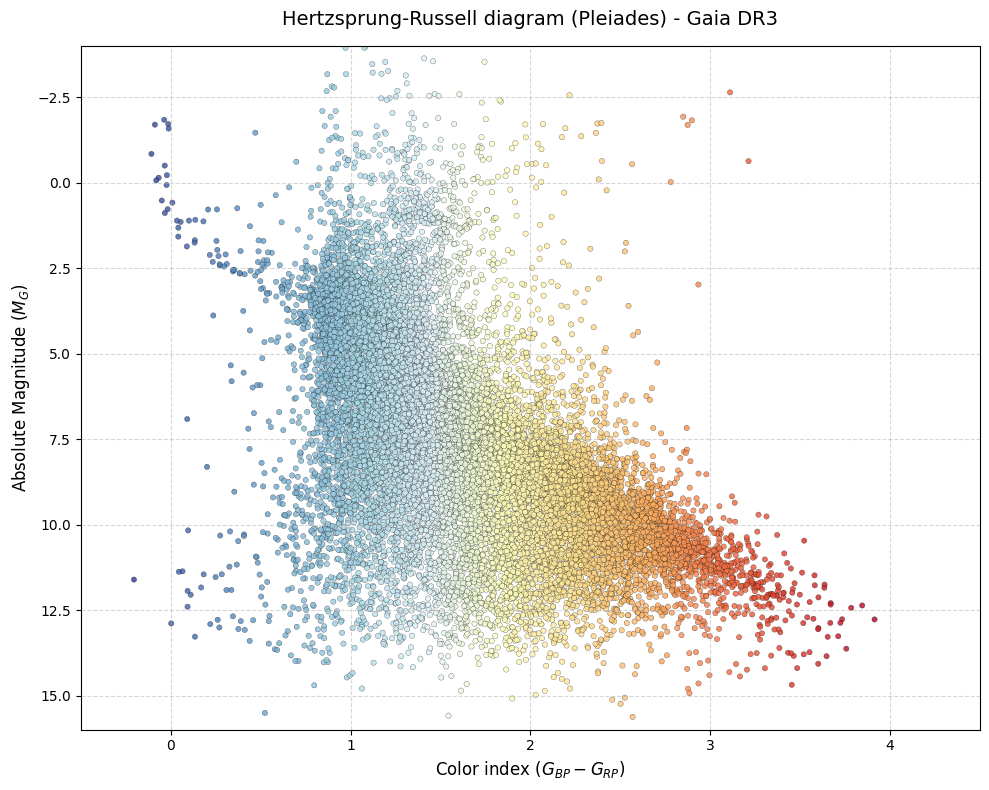

In [ ]:
# Calculate the absolute g using the naive approach
pc_distance = 1000.0 / df_gaia['parallax'] # Gaia used 'mas' instead of pc
df_gaia['absolute_g'] = df_gaia['phot_g_mean_mag'] - 5.0 * np.log10(pc_distance) + 5.0 # Absolute and observational magnitude relation

# Color idx: BP - RP
df_gaia['bp_rp'] = df_gaia['phot_bp_mean_mag'] - df_gaia['phot_rp_mean_mag']

# HR diagrama
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_gaia['bp_rp'], df_gaia['absolute_g'], c=df_gaia['bp_rp'], cmap='RdYlBu_r', 
                s=15, edgecolor='black', linewidths=0.2, alpha=0.8)

plt.gca().invert_yaxis()
plt.title('Hertzsprung-Russell diagram (Pleiades) - Gaia DR3', fontsize=14, pad=15)
plt.xlabel('Color index ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.5, 4.5)
plt.ylim(16, -4) 
plt.tight_layout()
plt.show()


We can observe that, although the H-R diagram displays the expected overall morphology (namely, the most luminous stars are located at the top of the diagram, and stars with high surface temperatures are on the left side), the plot exhibits significant scatter and noise. Specifically, we can see a grouping of stars in the lower-left quadrant (sources with high absolute magnitude and a lower color index).


To investigate this behaviour, let us first denote the parallax fractional error, which is computed directly from the sample measurement as $f = \frac{\sigma_{\varpi}}{\varpi}$ (Bailer-Jones, 2015). Taking its reciprocal yields the signal-to-noise ratio of the parallax measurement:

$$
f = \frac{\sigma_{\varpi}}{\varpi} = \frac{1}{\mathrm{SNR}},
\qquad
\mathrm{SNR} = \frac{\varpi}{\sigma_{\varpi}}.
$$

Now, according to the analyses by Lutz and Kelker (1973) and Bailer-Jones (2015), the parallax measurement error becomes unstable as a distance estimator when $f > 0.2$, which translates to a permissible signal-to-noise ratio of $\mathrm{SNR} > 5$.

In [13]:
df_gaia["snr"] = (df_gaia["parallax_error"] / df_gaia["parallax"])
highly_biased_measures = (df_gaia["snr"] <= 5).mean() 
print(f"Percentage of distances which are highly biased: {highly_biased_measures * 100}%")

Percentage of distances which are highly biased: 96.09836722428128%


Most stars in the sample are significantly biased in their parallax measurements; consequently, the associated calculated metrics (e.g., absolute magnitude) are also biased. At first glance, this may explains the general scatter and noise in the previous H-R diagram. However, this does not explain the earlier observated concentration of stars in the lower-left region of the Hertzsprung-Russell diagram. To investigate this feature, we first analyze the distribution of highly biased stars ($\mathrm{SNR} \leq 5$) across different regions of the diagram.

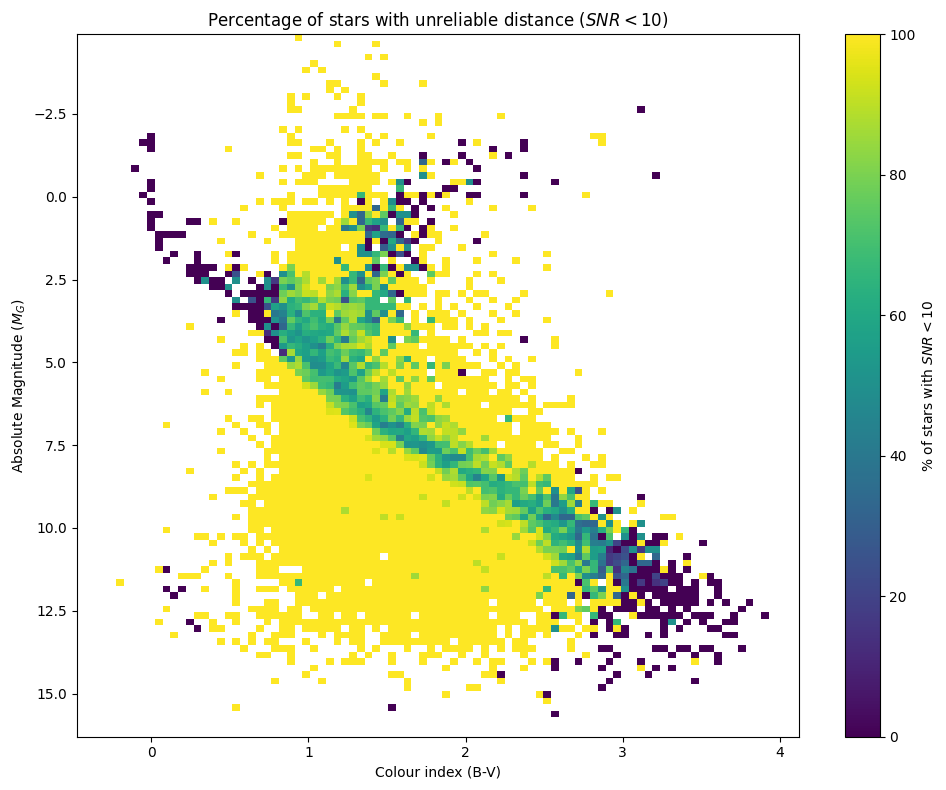

In [14]:
# Stars with unreliable distance
df_gaia["bad_distance"] = df_gaia["parallax_over_error"] < 10

color_bins = np.arange(-0.5, 4.2, 0.05)
mag_bins = np.arange(-5, 16.5, 0.2)
df_gaia["color_bin"] = pd.cut(df_gaia["bp_rp"], color_bins)
df_gaia["mag_bin"] = pd.cut(df_gaia["absolute_g"], mag_bins)

# Percentage of stars with unreliable distance 
heat = (
    df_gaia
    .groupby(["mag_bin", "color_bin"], observed=False)["bad_distance"]
    .mean()
    .unstack()
    * 100
)

x = [i.mid for i in heat.columns]
y = [i.mid for i in heat.index]

plt.figure(figsize=(10,8))

im = plt.imshow(
    heat,
    origin="lower",
    aspect="auto",
    extent=[x[0], x[-1], y[0], y[-1]],
    cmap="viridis",
    vmin=0,
    vmax=100
)

plt.gca().invert_yaxis()
plt.xlabel(r"Colour index (B-V)")
plt.ylabel(r"Absolute Magnitude ($M_G$)")
plt.title("Percentage of stars with unreliable distance ($SNR<10$)")
cbar = plt.colorbar(im)
cbar.set_label("% of stars with $SNR<10$")
plt.tight_layout()
plt.show()

## Lutz-Kelker bias

Lutz and Kelker (1973) analyzed the problem of star selection by imposing a “minimum limit” on observed parallax, which introduces a systematic error. Since instruments have errors, some stars that are actually outside this limit (further away) will be overestimated and included in the sample. At the same time, some stars that should be inside (closer) will be underestimated and excluded because, at greater distances, the volume of space is much larger; there are far more stars outside waiting to “sneak in” by error than there are stars inside that might be excluded. 


Geometric analysis at the boundary ($\pi'$) shows that since the geometry of space is not symmetric (stars are uniformly distributed throughout the universe, so the number of stars per parallax interval varies drastically as $1/\pi^4$). Mathematically, this means there is an overwhelmingly larger number of stars with smaller (more distant) true parallaxes. Thus, the vast majority of stars that register as $\pi'$ come from that enormous, textured cluster of distant stars that were pushed upward by measurement noise. Consequently, the average true parallax of those stars will always be less than the measured value $\pi'$.

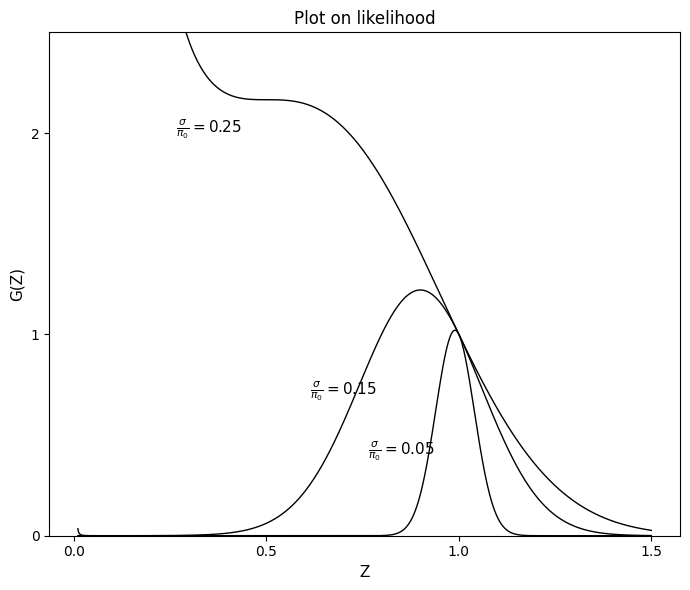

In [7]:
# Likelihood
def G(Z, s_p):
    """
    Z: X axis
    s_p: Y axis (sigma / pi_0)
    """
    # No division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        return (1 / Z**4) * np.exp(-((Z - 1)**2) / (2 * (s_p**2)))

Z = np.linspace(0.01, 1.5, 1000)
params = [0.25, 0.15, 0.05]

plt.figure(figsize=(7, 6))
for s_p in params:
    plt.plot(Z, G(Z, s_p), color='black', linewidth=1)

plt.ylim(0, 2.5)
plt.xlabel('Z', fontsize=11)
plt.ylabel('G(Z)', fontsize=11)
plt.xticks([0, 0.5, 1.0, 1.5])
plt.yticks([0, 1.0, 2.0])
plt.text(0.35, 2.0, r'$\frac{\sigma}{\pi_0}=0.25$', fontsize=11, ha='center')
plt.text(0.7, 0.7, r'$\frac{\sigma}{\pi_0}=0.15$', fontsize=11, ha='center')
plt.text(0.85, 0.4, r'$\frac{\sigma}{\pi_0}=0.05$', fontsize=11, ha='center')
plt.title(label="Plot on likelihood")
plt.tight_layout()
plt.show()